In [10]:
# !pip install matplotlib
# !pip install ipywidgets


In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
import sys
from pathlib import Path

# путь к папке src
src = Path("/workspace/skoltech/AdvancedControlMethods/project_1_Lyapunov_based_control_TBD/src")
if str(src) not in sys.path:
    sys.path.append(str(src))

import numpy as np
from simulation import TrackedRobotSim, go_to_pose_controller
from visualization import Visualizer

In [3]:
goal = np.array([10.0, 5.0])

sim = TrackedRobotSim(
    dt=0.05,
    xlim=(-2, 13),
    ylim=(-2, 8),
    state=[0.0, 0.0, 0.0],
)

ctrl = go_to_pose_controller(target_xy=goal, v_max=2.5, w_max=3.0)
sim.run(ctrl, steps=1200, command_mode="vw")

print("steps:", len(sim.history))
print("final pose:", sim.pose)
print("goal error:", np.hypot(sim.pose[0] - goal[0], sim.pose[1] - goal[1]))

steps: 1201
final pose: [10.          5.          0.46364761]
goal error: 1.1916163935586911e-14


Запуск симуляции...
Симуляция завершена за 1201 шагов.
Финальная ошибка до цели: 0.000 м


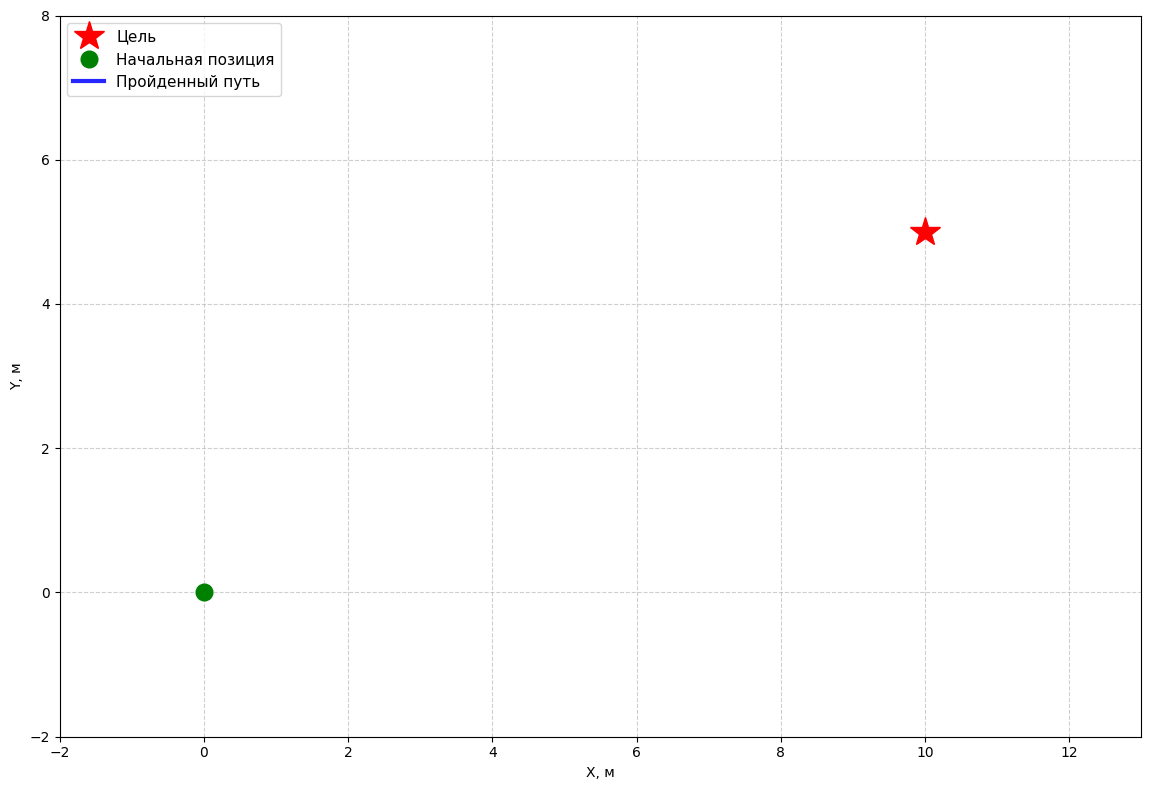

In [3]:
sim = TrackedRobotSim(
    dt=0.05,
    body_length=1.0,
    body_width=0.7,
    track_length=1.2,
    track_width=0.18,
    track_gap=0.34,
    max_track_speed=3.0,
    xlim=(-2, 13),
    ylim=(-2, 8),
    state=[0.0, 0.0, 0.0],
)

goal = np.array([10.0, 5.0])

# Контроллер (из simulation.py)
controller = go_to_pose_controller(
    target_xy=goal,
    target_theta=None,
    k_rho=1.8,
    k_alpha=4.2,
    k_beta=-1.2,
    v_max=2.5,
    w_max=3.0,
)

print("Запуск симуляции...")
sim.run(controller, steps=1200, command_mode="vw")

print(f"Симуляция завершена за {len(sim.history)} шагов.")
print(
    f"Финальная ошибка до цели: {np.hypot(sim.pose[0] - goal[0], sim.pose[1] - goal[1]):.3f} м"
)

# Создаём визуализатор и запускаем анимацию
vis = Visualizer(
    sim=sim,
    goal=goal,
    title="Гусеничный робот → цель (без препятствий)",
    show_controls=True,
)

ani = vis.render(realtime=True, repeat=True)